#EJERCICIO DE DESCRIPTIVA BÁSICA
##Objetivo
Revisar aspectos estadísticos e interpretativos de los análisis descriptivos en un ejercicio sencillo
##Librerías
A continuación instalaremos o cargaremos las librerías necesarias para nuestro trabajo: readxl para leer archivos de Excel, psych para descriptiva, y e1071

In [ ]:
install.packages(c("psych","e1071"))
library(psych)
library(readxl)
library(e1071)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘proxy’




In [ ]:
install.packages("DataExplorer")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘plyr’, ‘igraph’, ‘reshape2’, ‘gridExtra’, ‘networkD3’




In [ ]:
install.packages(c("GGally","ggmosaic","summarytools"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘labelled’, ‘broom.helpers’, ‘patchwork’, ‘lobstr’, ‘ggstats’, ‘checkmate’, ‘magick’, ‘matrixStats’, ‘pander’, ‘pryr’, ‘rapportools’


Warning message in install.packages(c("GGally", "summarytools")):
“installation of package ‘magick’ had non-zero exit status”
Warning message in install.packages(c("GGally", "summarytools")):
“installation of package ‘summarytools’ had non-zero exit status”


##Importación de datos en archivos de texto
Una vez ubicados los archivos a importar en el directorio de trabajo, se puede proceder a la importación. En este caso importaremos un archivo separados por comas (csv) con el que trabajaremos




In [ ]:
cartera<-read.csv("cartera.csv", header=TRUE, sep=";", dec=",")

Nótese que hemos establecido que el archivo tiene los nombres de las variables en el encabezado (header=TRUE) y que el separador es “;”(sep=“;”) y el separador de decimales es la coma (dec=“,”), todo lo cual puede o no ser necesario dependiendo del archivo que se tenga.

El archivo contiene datos de clientes de un proveedor de instituciones de salud (IPS), la cartera que presentan y si se han retrasado o no. Se trata entonces de un negocio B2B en el sector de la salud que desea predecir o averiguar indicadores de posibles aumentos y retrasos en su cartera

##Lectura de archivos de Excel
Ahora sí podemos leer el archivo Excel requerido con una función del paquete readxl y vemos sus primeras lineas con la instrucción “head”

In [ ]:
telco<-read_excel("services2.xls")
head(telco)

minutes,score,bill
<dbl>,<dbl>,<dbl>
276.5,64.97563,501
189.0,52.64984,400
197.5,63.71926,217
256.8,72.10529,82
274.8,83.44579,306
207.3,70.40846,216


El archivo contiene 3 variables de clientes de una empresa de telefonía móvil. Sus minutos de consumo, su valor de factura, y su propensión a dejar la empresa (churn).
##Tipos de variables y modificaciones a los mismos

Si bien hay múltiples tipos de datos en R, es necesario familiarizarse inicialmente con dos: Categóricos (factor) y escalares (num o numeric). Se puede usar la función str para conocer los tipos de datos de toda la base de datos

In [ ]:
str(cartera)

'data.frame':	852 obs. of  9 variables:
 $ MESES             : int  41 27 40 41 24 41 39 43 24 36 ...
 $ tipoips           : int  3 1 1 1 2 2 1 1 1 1 ...
 $ igualowner        : int  17 10 15 15 2 5 20 12 3 0 ...
 $ yearsadress       : int  12 6 14 14 0 5 9 11 4 13 ...
 $ ventasmesaverage  : int  176 31 55 120 28 25 67 38 19 25 ...
 $ pasivo_sobre_venta: num  9.3 17.3 5.5 2.9 17.3 10.2 30.6 3.6 24.4 19.7 ...
 $ carteraA          : num  11.36 1.36 0.86 2.66 1.79 ...
 $ carteraB          : num  5.01 4 2.17 0.82 3.06 ...
 $ retrasos          : int  1 0 0 0 1 0 0 0 1 0 ...


En esta base de datos tenemos variables tipo int (entero), tipo num( numérico) y tipo factor (categóricos). Estos últimos se marcan con los niveles o categorías que tienen. Si se quiere ver la clasificación de una sola variable se usa

In [ ]:
class(cartera$yearsadress)
class(cartera$retrasos)

[1] "integer"

[1] "integer"

La variable yearsadress, que representa los años en la dirección actual, está mal clasificada como categórica cuando debe ser numérica. La variable retrasos, al ser binaria, puede ser reclasificada como categórica. Hagámoslo:

In [ ]:
cartera$yearsadress<-as.numeric(cartera$yearsadress)
cartera$retrasos<-as.factor(cartera$retrasos)

Ahora estamos listos para realizar algunos análisis a nuestros archivos.
##Descriptiva básica en R
###Resumen básico y selección de subconjuntos

Básicamente cualquier modelo o función estadística en R tiene al menos dos funciones: un resumen (summary) y un gráfico (plot). Pero miremos las diferencias entre estas 3 instrucciones:

    minutes          score            bill       
 Min.   : 53.6   Min.   :16.71   Min.   :   9.0  
 1st Qu.:131.8   1st Qu.:33.03   1st Qu.: 104.2  
 Median :158.4   Median :37.92   Median : 205.5  
 Mean   :162.2   Mean   :41.54   Mean   : 278.2  
 3rd Qu.:188.8   3rd Qu.:44.86   3rd Qu.: 343.8  
 Max.   :326.3   Max.   :83.45   Max.   :1667.0  

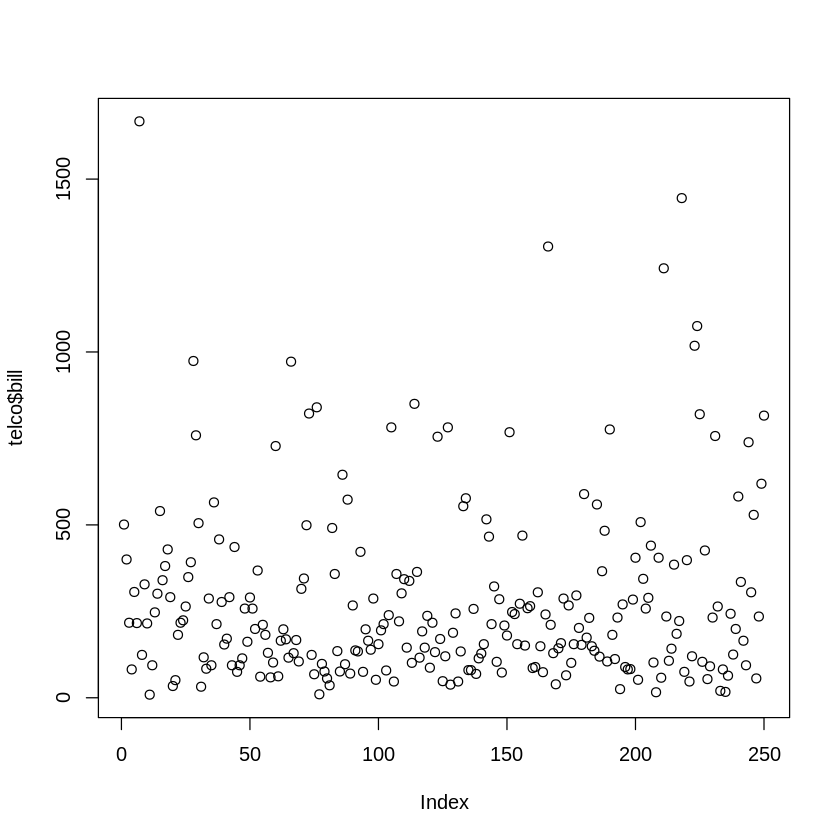

In [ ]:
summary(telco)
plot(telco$bill)

Como podemos ver, la instrucción summary sobre una variable obtiene los valores mínimo, máximo y los cuartiles de la variable. Con estos valores se puede revisar si tien sentido o no el contexto del negocio los valores. Por ejemplo, el score que es una propensión a retirarse de la empresa (churn) está entre 0 y 100 (más exactamente entre 16.7 y 83.45), lo que tiene sentido. La variable bill que representa la facturación, no puede estar en pesos dados sus valores (está en dólares). El consumo en minutos puede o no tener sentido dependiendo de la lógica de negocio.

Aunque el gráfico no es muy informativo, si que son visibles algunos datos atípicos de facturación.
###medidas estadísticas: Tendencia central, dispersión y forma

In [ ]:
attach(telco)
mean(bill)
median(bill)
mean(bill, trim=0.2)

[1] 278.152

[1] 205.5

[1] 211.1667

Se observa una diferencia llamativa entre media y mediana; la media recortada implica datos extremos de facturación, como ya habíamos visto. Esta tendencia central es tambien un posible indicador/meta de negocio: estamos por encima o por debajo de la facturación media que esperamos?

Ahora vamos a obtener un grupo de medidas de dispersión:

In [ ]:
range(bill)
var(bill)
sd(bill)
mad(bill)


[1]    9 1667

[1] 67235.96

[1] 259.299

[1] 161.6034

La desviación estándar luce alta, mucho más alta que la desviación media o mad, lo que corrobora nuestra impresión de atípicos. Sin embargo para saber qué tan alta es la dispersión, con frecuencia se compara la desviación estándar con la media, mediante el coeficiente de variación si las variables son claramente superiores a cero. Sin embargo R no tiene construída una función para el coeficiente de variación (CV). Creéemoslo:

In [ ]:
cv=(100*sd(bill))/mean(bill)
cv

[1] 93.22204

Pero si deseamos usarlo en múltiples ocasiones, lo mejor es crear una función:

In [ ]:
CV <- function(var){(sd(var)/mean(var))*100}
CV(bill)

[1] 93.22204

Ahora vamos a utilizar la función apply para mostrar la forma de aplicar múltiples veces la misma función dentro de una base de datos, en este caso el CV para todas las columnas de la base de datos:

In [ ]:
apply(telco,2,CV)

minutes    score     bill 
28.71608 32.07618 93.22204

La variable bill es efectivamente la de mayor variación alrededor de su media, mientras los minutos gastados son bastante menos variables. En constraste, la relativamente baja variabilidad de los minutos (minutes) puede permitir una mejor planeación de los recursos operativos para satisfacer la demanda que se enfrenta. Ahora, por qué si el consumo de minutos es poco variable, la factura si lo es? Una posible especulación gira alrededor de los servicios adicionales (internet, juegos, etc…)

El 2 dentro de la función apply implica que se hace la función para todas las columnas; si se usara 1 funcionaría para todas las filas.

Ahora vamos a mostrar un paquete(librería) que hace múltiples descriptivos para un dataframe.
Dado el volumen de información que algunas salidas de R producen, puede ser interesante guardarlas en un dataframe.

In [ ]:
describe(telco)
telcostat<-describe(telco)
str(telco)

,vars,n,mean,sd,median,trimmed,mad,min,max,range,skew,kurtosis,se
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
minutes,1,250,162.18600,46.57346,158.45000,159.71900,41.883450,53.60000,326.30000,272.70000,0.5432664,0.3843731,2.9455644
score,2,250,41.53951,13.32429,37.91543,40.08798,8.193597,16.71054,83.44579,66.73524,1.0235001,0.4340992,0.8427018
bill,3,250,278.15200,259.29898,205.50000,229.83500,161.603400,9.00000,1667.00000,1658.00000,2.1444295,5.8027329,16.3995074


tibble [250 × 3] (S3: tbl_df/tbl/data.frame)
 $ minutes: num [1:250] 276 189 198 257 275 ...
 $ score  : num [1:250] 65 52.6 63.7 72.1 83.4 ...
 $ bill   : num [1:250] 501 400 217 82 306 ...


AL observar los resultados, llama la atención la alta tendencia central de score. Ese es un indicador de alerta para el negocio. Su asimetría positiva indica que probablemente hay más scores altos de lo esperado (o que hay scores muy altos, pero dado que hay un límite máximo al valor de scores, está no es probablemente la interpretación). Así mismo tenemos para *bill*, altas curtosis (signo de atípicos) y alta asimetría positiva, que contrasta con la baja asimetría y curtosis de minutos.
Vamos a adicionar el CV a esta base de datos y luego calcular un estadístico a lo largo de las variables , en este caso, la media geométrica de los CVs.

In [ ]:
cvs<-apply(telco,2,CV)
telcostat2<-cbind(telcostat,cvs)
geometric.mean(telcostat2$cvs)
telcostat2

[1] 44.11729

,vars,n,mean,sd,median,trimmed,mad,min,max,range,skew,kurtosis,se,cvs
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
minutes,1,250,162.18600,46.57346,158.45000,159.71900,41.883450,53.60000,326.30000,272.70000,0.5432664,0.3843731,2.9455644,28.71608
score,2,250,41.53951,13.32429,37.91543,40.08798,8.193597,16.71054,83.44579,66.73524,1.0235001,0.4340992,0.8427018,32.07618
bill,3,250,278.15200,259.29898,205.50000,229.83500,161.603400,9.00000,1667.00000,1658.00000,2.1444295,5.8027329,16.3995074,93.22204




Para obtener medidas de posición puede ser importante pasar un vector que diga cuáles cuantiles queremos

In [ ]:
quantile(bill)

0%     25%     50%     75%    100% 
   9.00  104.25  205.50  343.75 1667.00

In [ ]:
quantile(bill, c(.10,.45,.90))


10%   45%   90% 
 63.8 180.1 582.7

In [ ]:
cuantiles<-apply(telco,2,quantile)
cuantiles

,minutes,score,bill
0%,53.600,16.71054,9.00
25%,131.775,33.02794,104.25
50%,158.450,37.91543,205.50
75%,188.825,44.86186,343.75
100%,326.300,83.44579,1667.00


Si bien el 90% de los clientes tienen facturas de 582.7 dólares o menos, el máximo es de más del doble (1667 dpolares)


###Gráficos univariados

Ahora vamos a ver unos gráficos univariados básicos:

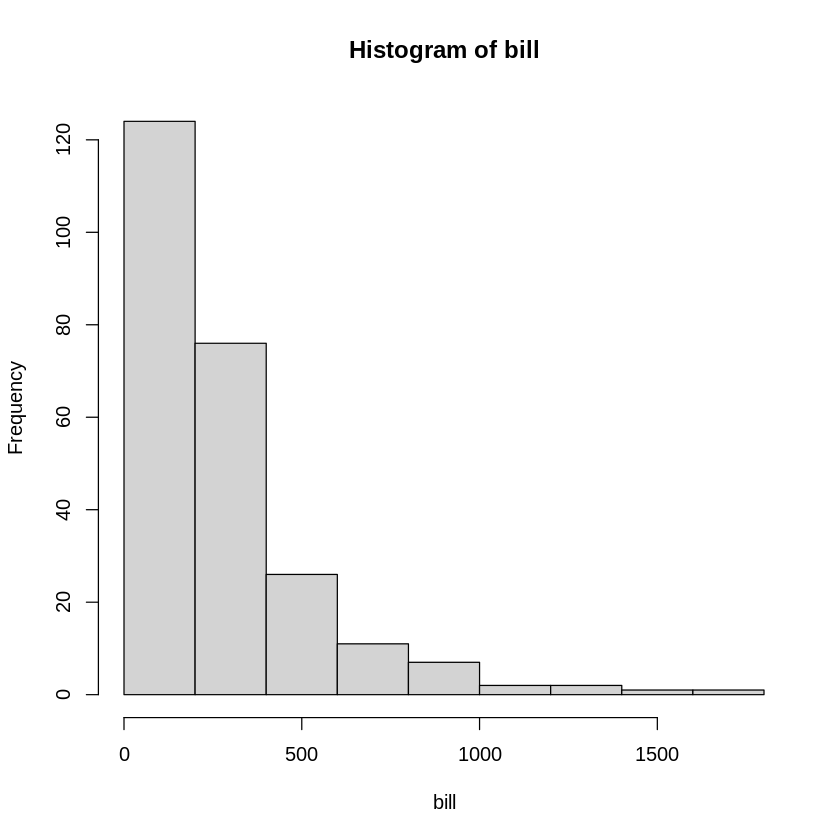

In [ ]:
hist(bill)

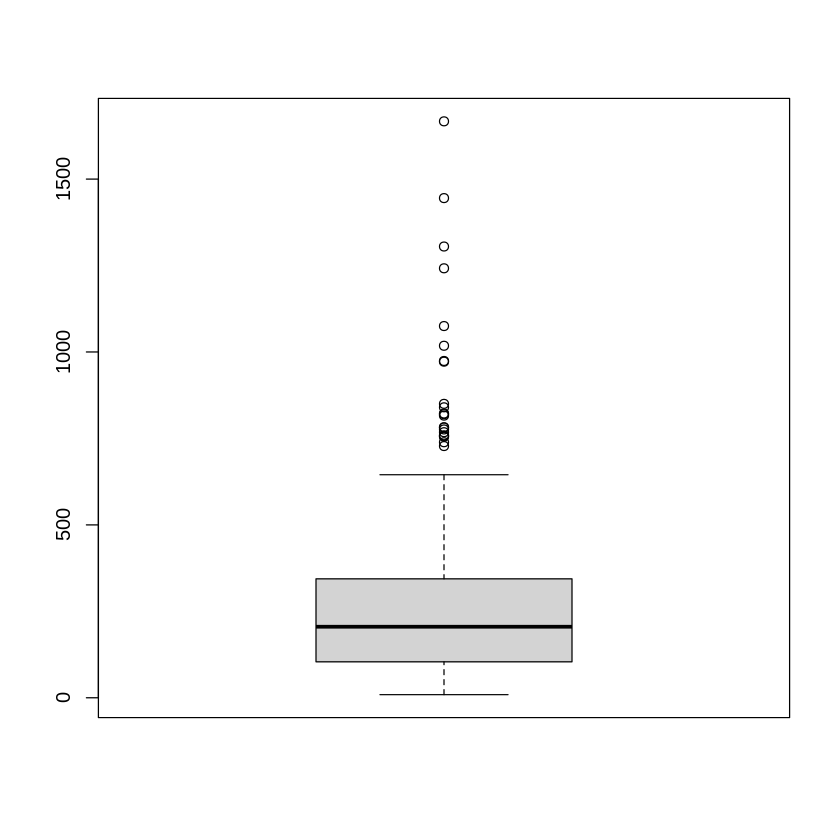

In [ ]:
boxplot(bill)

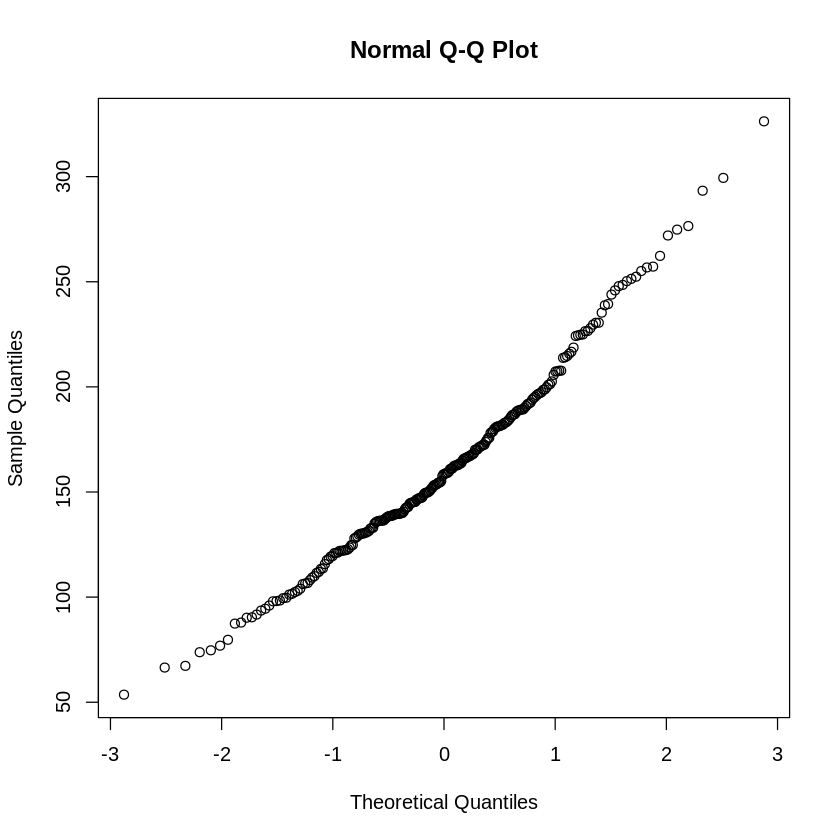

In [ ]:
qqnorm(minutes)

Son claramente observables: la asimetría positiva de bill (valores largos y más frecuentes de lo esperado en la cola) y su existencia de atípicos y una interesante cercanía a la curva normal del consumo en minutos.

Por supuesto los datos de los gráficos también se pueden guardar. Miremos su estructura.

List of 6
 $ stats: num [1:5, 1] 9 104 206 344 645
 $ n    : num 250
 $ conf : num [1:2, 1] 182 229
 $ out  : num [1:22] 1667 974 759 728 972 ...
 $ group: num [1:22] 1 1 1 1 1 1 1 1 1 1 ...
 $ names: chr "1"


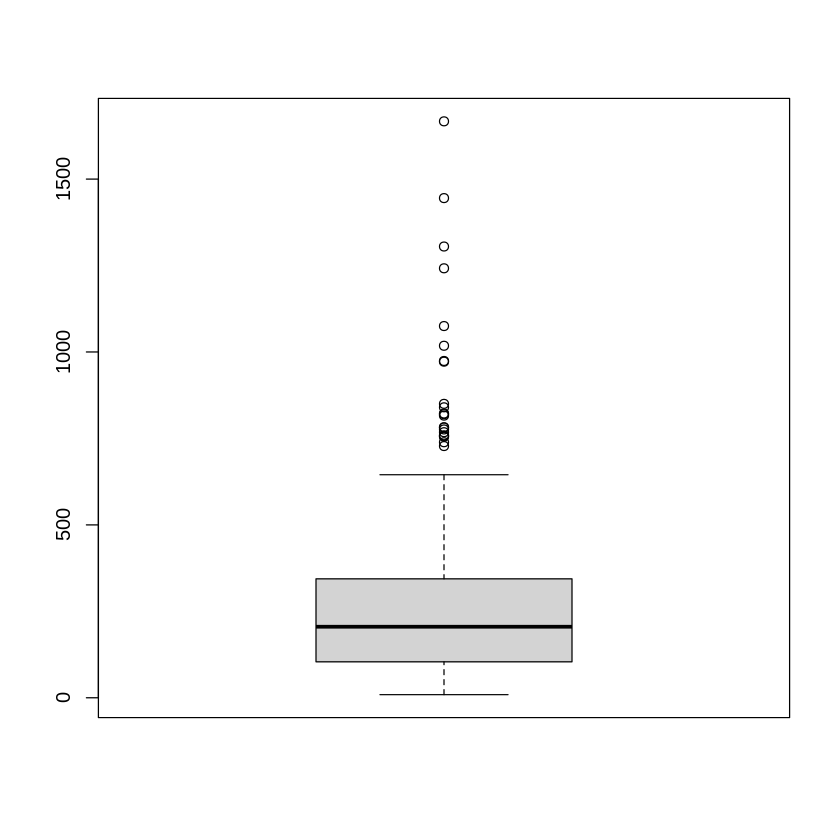

In [ ]:
boxguarda<-boxplot(bill)
str(boxguarda)

En un diagrama de caja y bigotes hay diferentes informaciones para guardar: los cuantiles, la cantidad de datos, y los atípicos. Esta infromación puede ser de diferentes longitudes o inclusive de diferente tipo de variables. Por eso se almacenan en una lista, que es en sí misma una colección de objetos diferentes (por ejemplo, vectores y matrices de diferentes dimensiones). Si solo quiero los atípicos, basta con llamarlos:

In [ ]:
boxguarda$out

[1] 1667  974  759  728  972  822  840  782  850  755  782  768 1305  776 1242
[16] 1445 1018 1075  820  757  739  816

###Descriptivos de variables categóricas

Para las variables categóricas usualmente se manejan tablas y gráficos de barras.

In [ ]:
table(cartera$tipoips)


  1   2   3   4   5 
462 235 101  49   5 

Para graficarlo, se guarda la tabla y se grafica:

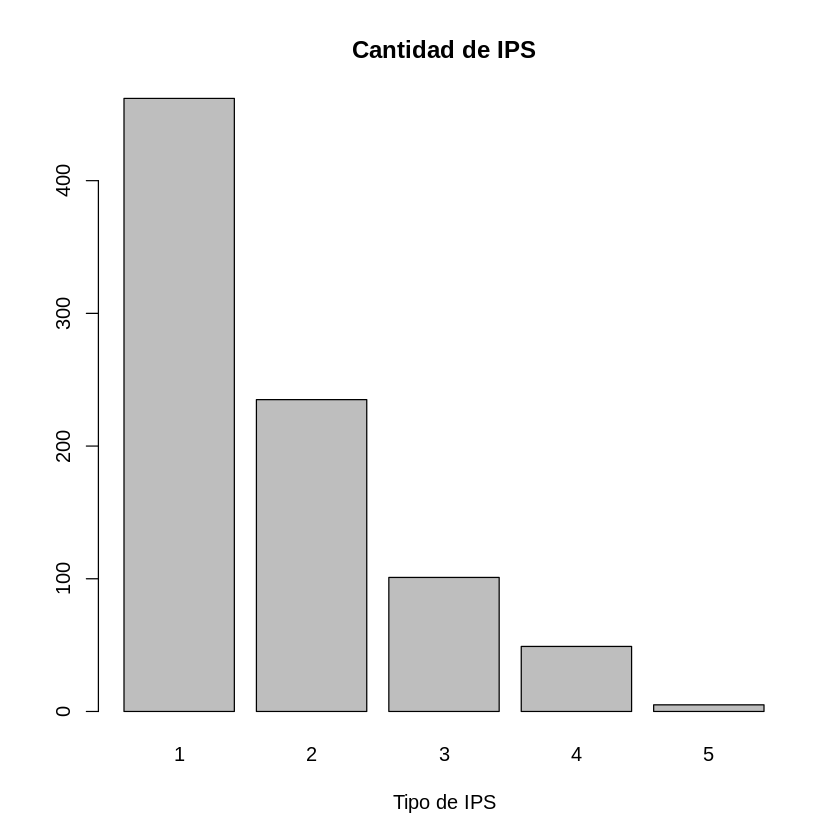

In [ ]:
tabla1<-table(cartera$tipoips)
barplot(tabla1, main="Cantidad de IPS", xlab="Tipo de IPS")

Con la tabla se pueden realizar algunos cálculos de frecuencias adicionales:

In [ ]:
prop.table(tabla1)

Esta variable marca la complejidad (tamaño) de la IPS en valores de 1 a 6. Tenemos algunos datos perdidos, y en general se presenta una estructura esperada: más clientes pequeños (de baja complejidad) y unos pocos clientes grandes.
Una medida interesante para una variable categórica es su entropia, que puede indicar qué tanta dispersión/uniformidad hay entre las categorías. Veamos:




In [ ]:
install.packages("infotheo")
library(infotheo)
cartera$tipoips<-as.factor(cartera$tipoips)
entropy(cartera$tipoips)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] 1.134315

La entropía directa es interpretable en términos de transmisión de información (i.e, bits o nats necesarios para comunicar la variable). Unas medidas más fácilmente interpretables serían la entropía relativa a su máximo y el número efectivo de especies (que puede leerse como el número de categorías que debiéramos tener y puede guiar la agrupación de categorías)

In [ ]:
##para que funcione la ecuación se debe trabajar con factores
entropia_relativa<-entropy(cartera$tipoips)/log(nlevels(cartera$tipoips))
especies<-exp(entropy(cartera$tipoips))
entropia_relativa
especies

[1] 0.7047897

[1] 3.109044

Esto indicaría que la entropía actual es un 70% de la entropía máxima (uniformidad) y que el número efectivo de categorías es inferior a las 5 actuales (un poco más de 3)

###Cruces básicos de variables
Para cruzar dos variables escalares, basta con usar plot con las dos variables. En este caso, al tener dos variables escalares, tendríamos un gráfico de dispersión.


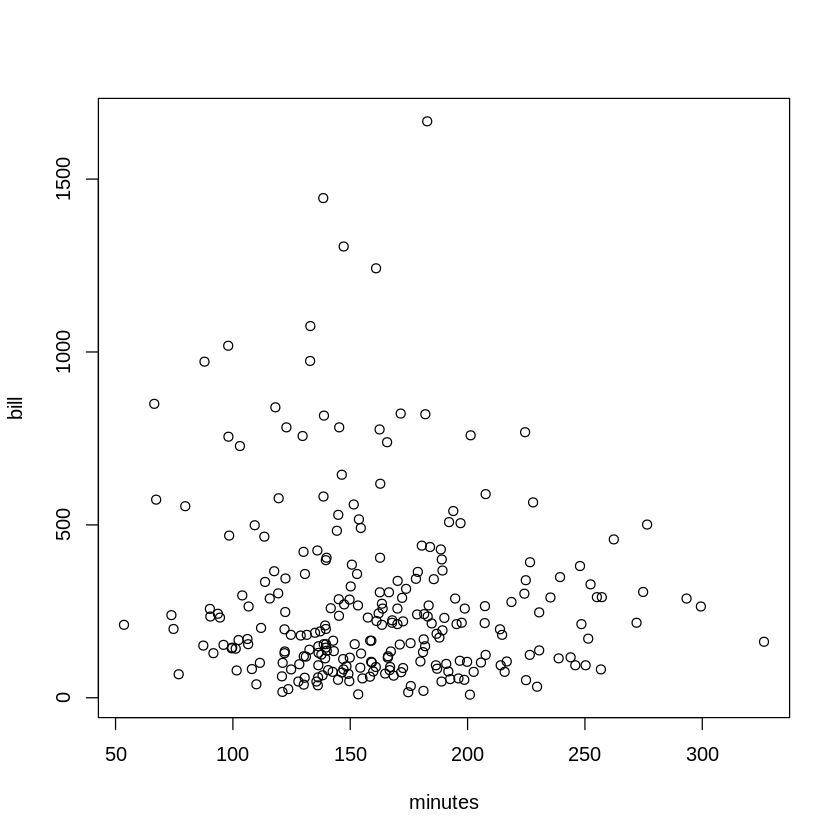

In [ ]:
plot(minutes, bill)

La medida descriptiva adecuada para comparar dos variables escalares (desde el punto de vista lineal) es la correlación

In [ ]:
cor(minutes, bill)

[1] -0.08329326

En este caso, queda aún más patente que los aumentos en la factura no se deben a los minutos. El consumo telefónico es solo un gancho para atraer a los clientes a productos más rentables.

Para cruzar una variable categórica con una escalar, se usa un diagrama de caja y bigotes dividido y descriptivos divididos:

0        1 
35.58725 32.94301

0        1 
7.790741 8.918722

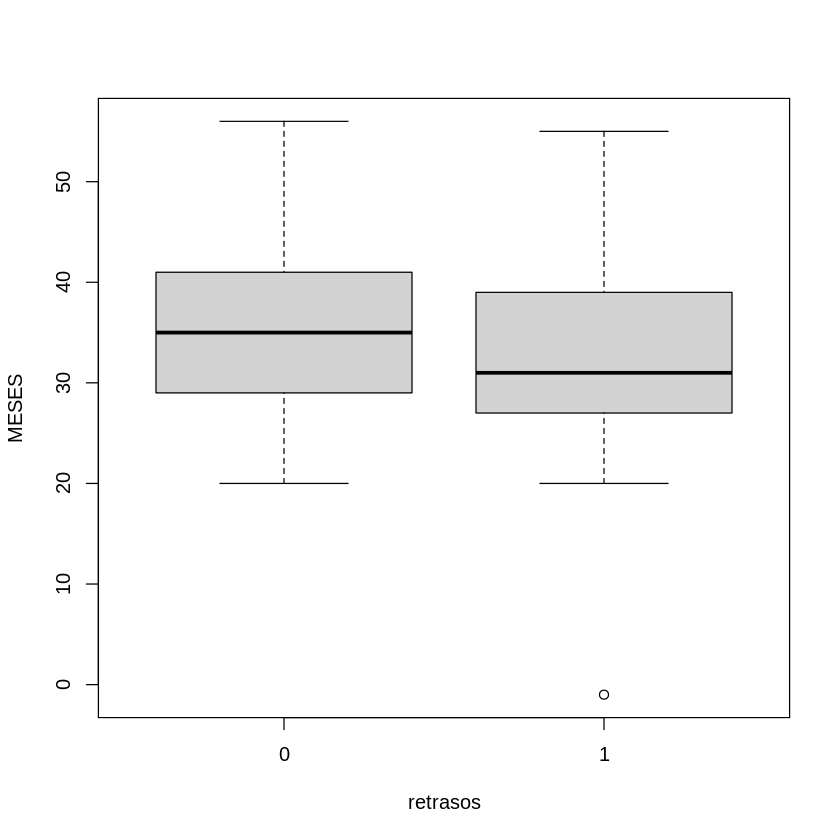

In [ ]:
boxplot(MESES~retrasos, data=cartera)
tapply(cartera$MESES, cartera$retrasos, mean)
tapply(cartera$MESES, cartera$retrasos, sd)

Al parecer, los clientes sin retrasos tienden a llevar más meses como clientes de la empresa. Para cruzar dos variables categóricas, lo usual es una tabla cruzada:

In [ ]:
table(cartera$tipoips, cartera$retrasos)

Con ciertas librerías es posible obtener algunas tablas más completas

In [ ]:
attach(cartera)
install.packages("gmodels")
library("gmodels")
CrossTable(tipoips, retrasos)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gtools’, ‘gdata’





 
   Cell Contents
|-------------------------|
|                       N |
| Chi-square contribution |
|           N / Row Total |
|           N / Col Total |
|         N / Table Total |
|-------------------------|

 
Total Observations in Table:  852 

 
             | retrasos 
     tipoips |         0 |         1 | Row Total | 
-------------|-----------|-----------|-----------|
           1 |       377 |        85 |       462 | 
             |     1.081 |     3.691 |           | 
             |     0.816 |     0.184 |     0.542 | 
             |     0.572 |     0.440 |           | 
             |     0.442 |     0.100 |           | 
-------------|-----------|-----------|-----------|
           2 |       174 |        61 |       235 | 
             |     0.332 |     1.133 |           | 
             |     0.740 |     0.260 |     0.276 | 
             |     0.264 |     0.316 |           | 
             |     0.204 |     0.072 |           | 
-------------|-----------|-----------|------

Y finalmente un gráfico con residuales de pearson:

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘zoo’, ‘lmtest’


Loading required package: grid



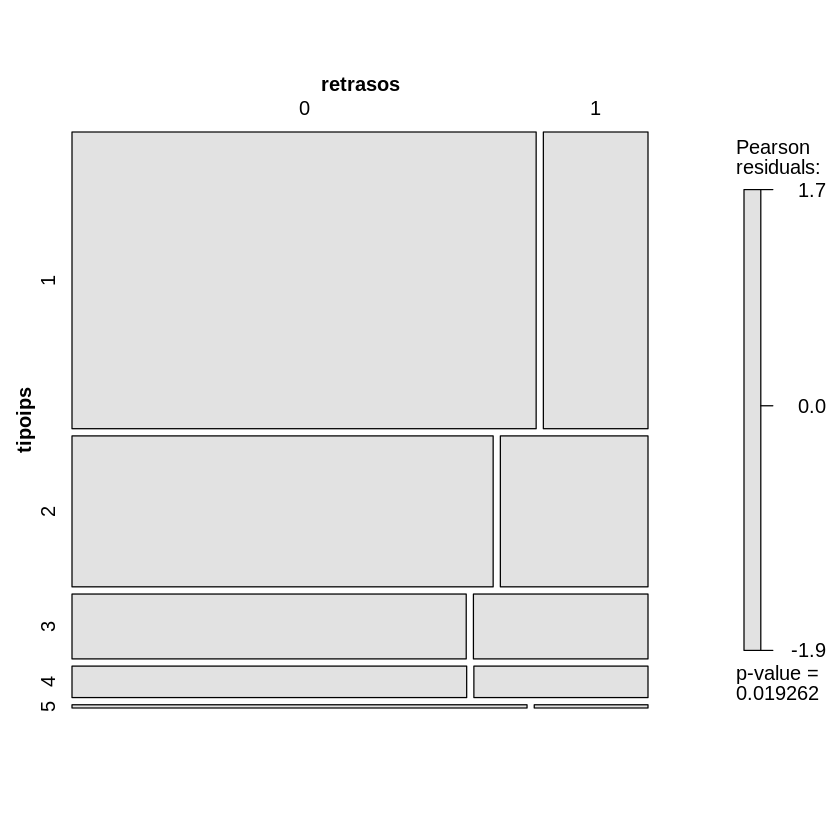

In [ ]:
install.packages("vcd")
library("vcd")
mosaic(~tipoips + retrasos,data=cartera,
       legend=TRUE, shade=TRUE)

No parece haber una relación entre el tamaño/complejidad de la IPS y si se retrasa o no. Veamos el estadístico básico adecuado, que nos indica que el resultado está muy cerca a los límites clásicos de la significancia:






In [ ]:
chisq.test(tipoips,retrasos)

Warning message in chisq.test(tipoips, retrasos):
“Chi-squared approximation may be incorrect”



	Pearson's Chi-squared test

data:  tipoips and retrasos
X-squared = 11.756, df = 4, p-value = 0.01926


En este ejemplo hemos hecho un repaso rápido de mecanismos descriptivos univariados y bivariados dependiendo del tipo de variable, y revisado algunas interpretaciones iniciales. Al final del mismo es importante reforzar los conceptos practicando con nuevas bases de datos o profundizando más en las aquí cargadas.
Para tener un mayor control y estética en los gráficos se sugiere trabajar con la información (notebooks de visualización)

##Librerías de resumen
En el siguiente apartado mostraremos algunas librerías de resumen que ayudan a visualizar rápidamente resultados descriptivos. Primero, para las variables escalares:

In [ ]:
library(summarytools)
describe_total<-descr(cartera)
describe_total


Luego para las categóricas

In [ ]:
freq(cartera,plain.ascii = FALSE, style = "rmarkdown")


In [ ]:
view(dfSummary(cartera))


Histogramas para todas las variables escalares

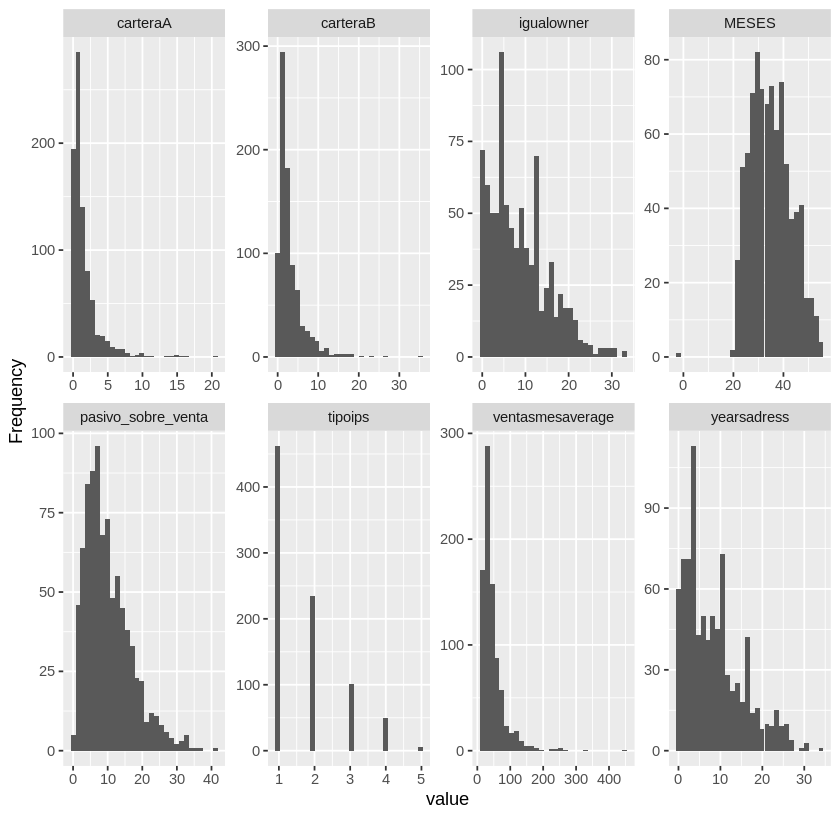

In [ ]:
library(DataExplorer)
plot_histogram(cartera)


Y luego para todas las variables categóricas, un gráfico de barras.

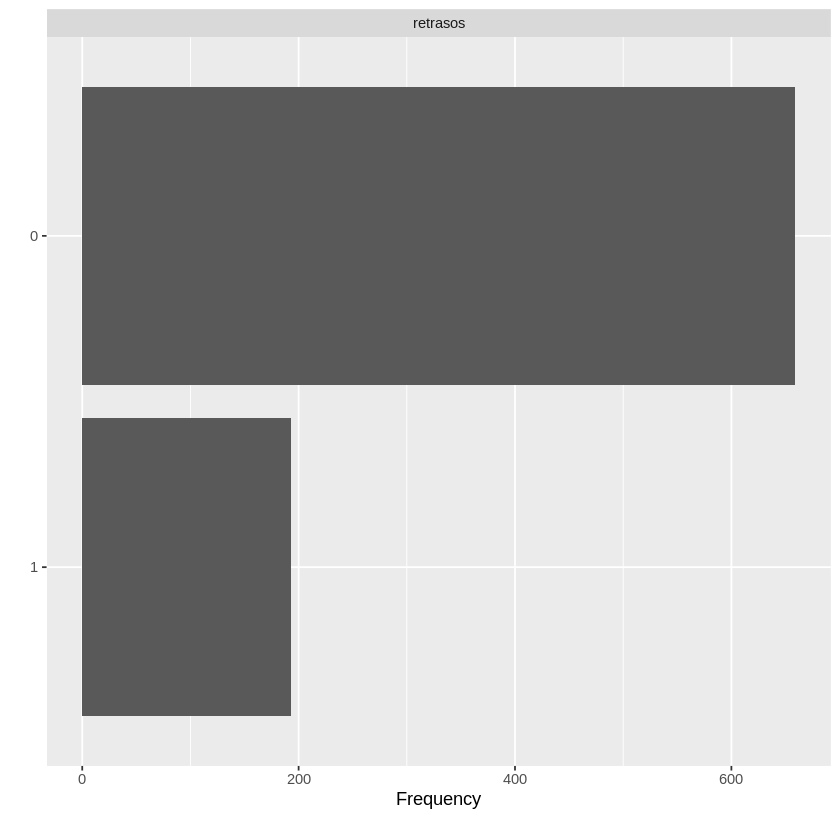

In [ ]:
plot_bar(cartera)


¿Qué dificultas surge si se desea un boxplot en un único gráfico para todas las variables escalares?

Ahora crucemos variables escalares (e incluyamos la descripitiva univariada)

Loading required package: ggplot2

Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2



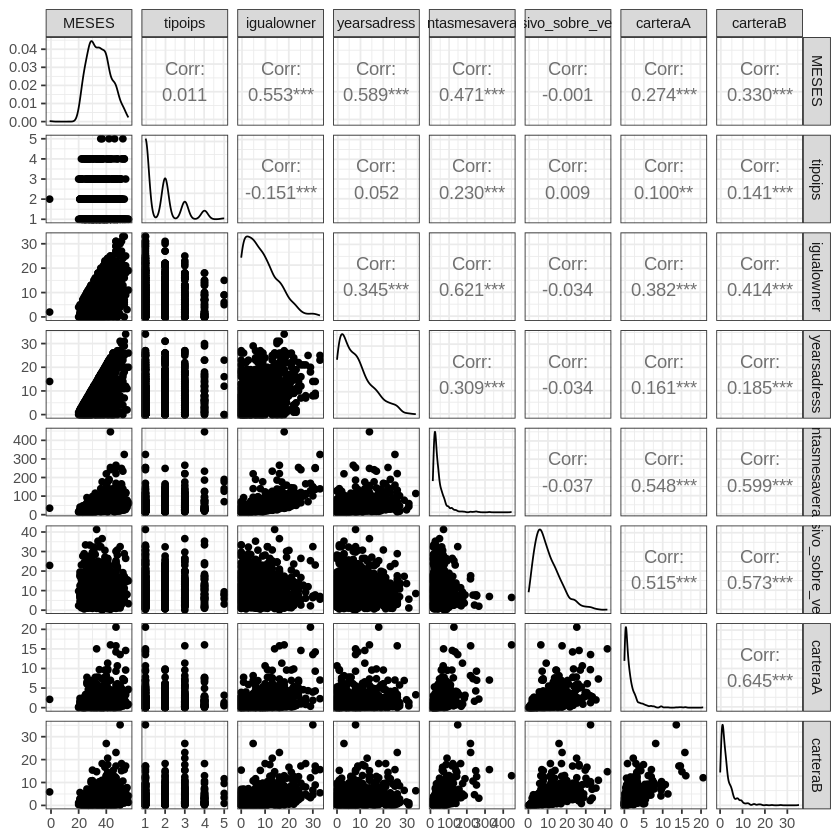

In [ ]:
library(GGally)
ggpairs(cartera[,-9])+ theme_bw()

Crucemos todas, y demos color por una variable categórica (aquí estamos agregando los cruces categórico/escalares)

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


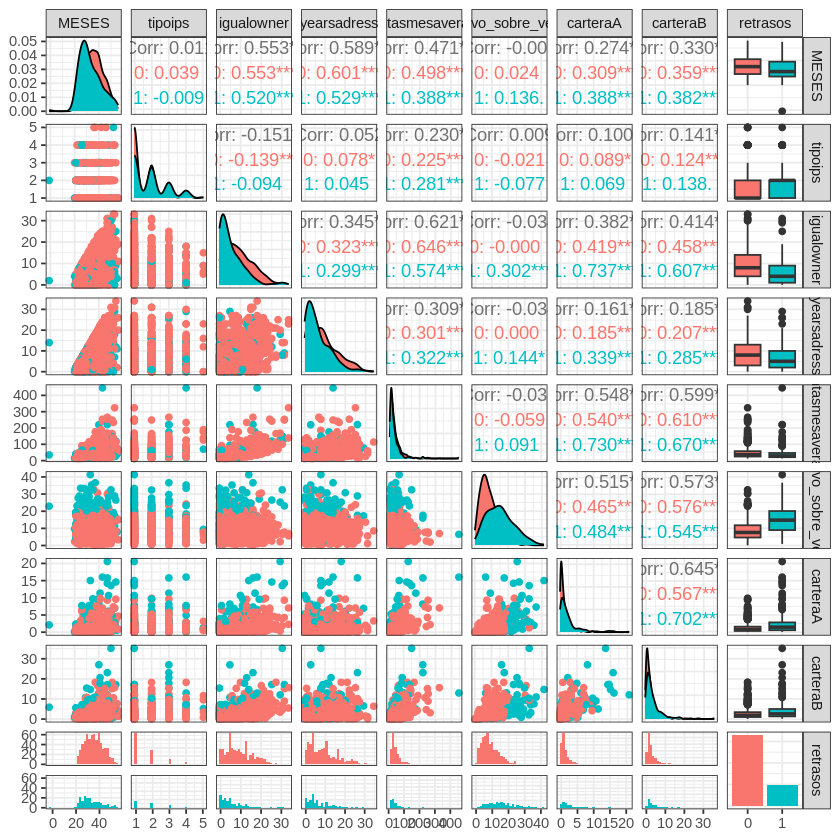

In [ ]:
ggpairs(cartera, aes(color=retrasos))+ theme_bw()


Otra opción de cruces categórico-escalares

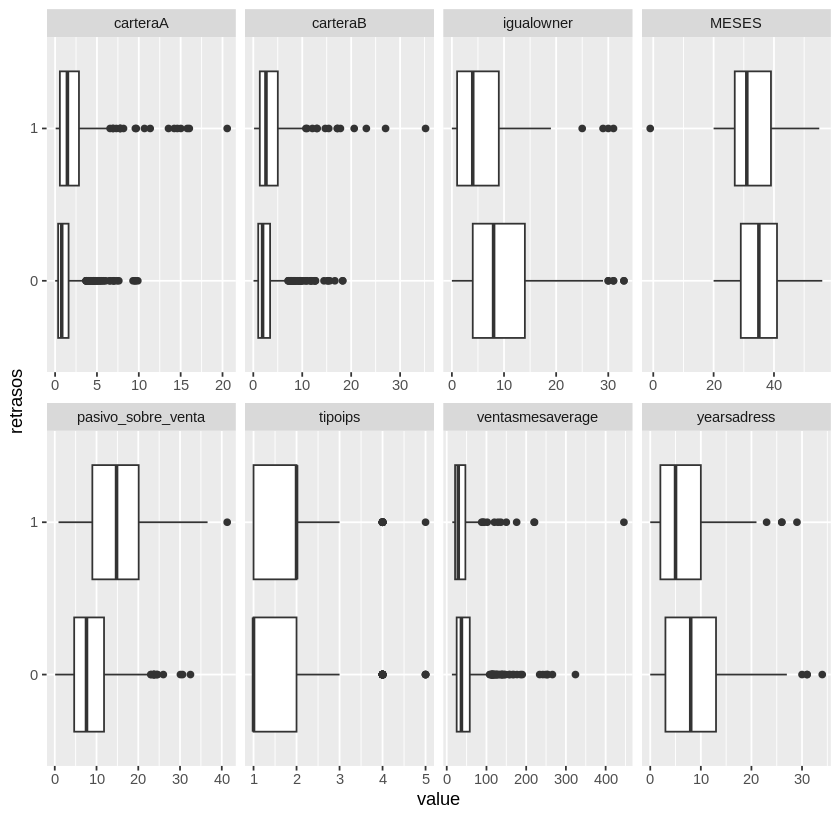

In [ ]:
plot_boxplot(cartera, by = "retrasos")

Los cruces categórico / categórico

In [ ]:
cartera$tipoips<-as.factor(cartera$tipoips)
ctable(x=cartera$tipoips,y=cartera$retrasos,digits=2,chisq=TRUE)



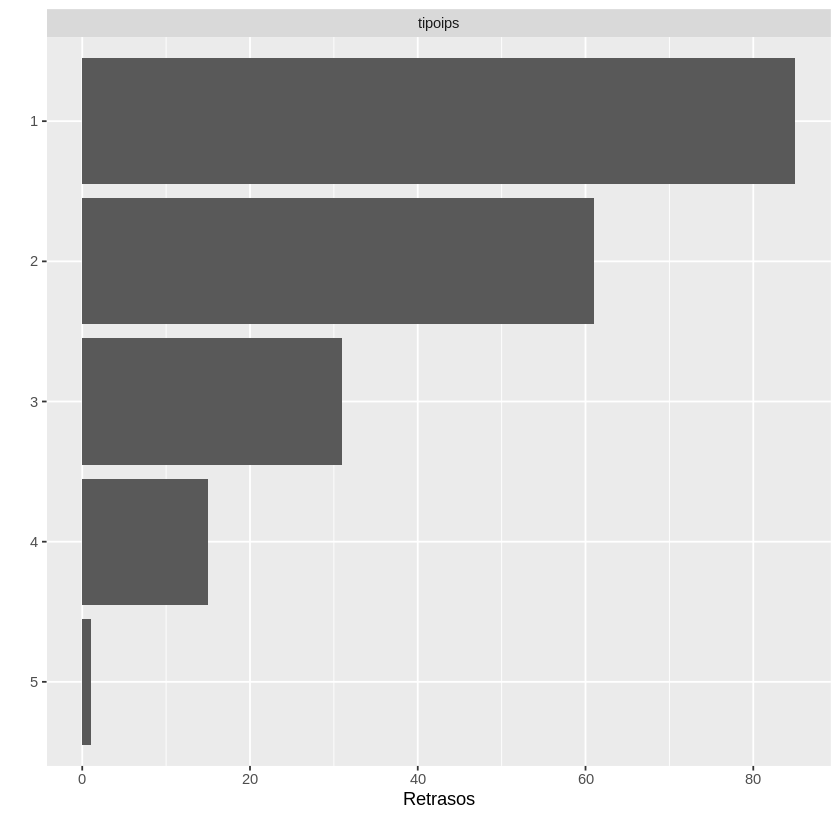

In [ ]:
plot_bar(cartera,with="retrasos")
##alternativa para alinearlos a un 100% by="retrasos"

In [ ]:
install.packages("ggmosaic")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘lazyeval’, ‘crosstalk’, ‘productplots’, ‘plotly’, ‘ggrepel’





Attaching package: ‘ggmosaic’


The following object is masked from ‘package:GGally’:

    happy


Warning message:
“The `scale_name` argument of `continuous_scale()` is deprecated as of ggplot2
3.5.0.”
Warning message:
“The `trans` argument of `continuous_scale()` is deprecated as of ggplot2 3.5.0.
ℹ Please use the `transform` argument instead.”
Warning message:
“`unite_()` was deprecated in tidyr 1.2.0.
ℹ Please use `unite()` instead.
ℹ The deprecated feature was likely used in the ggmosaic package.
  Please report the issue at <https://github.com/haleyjeppson/ggmosaic>.”


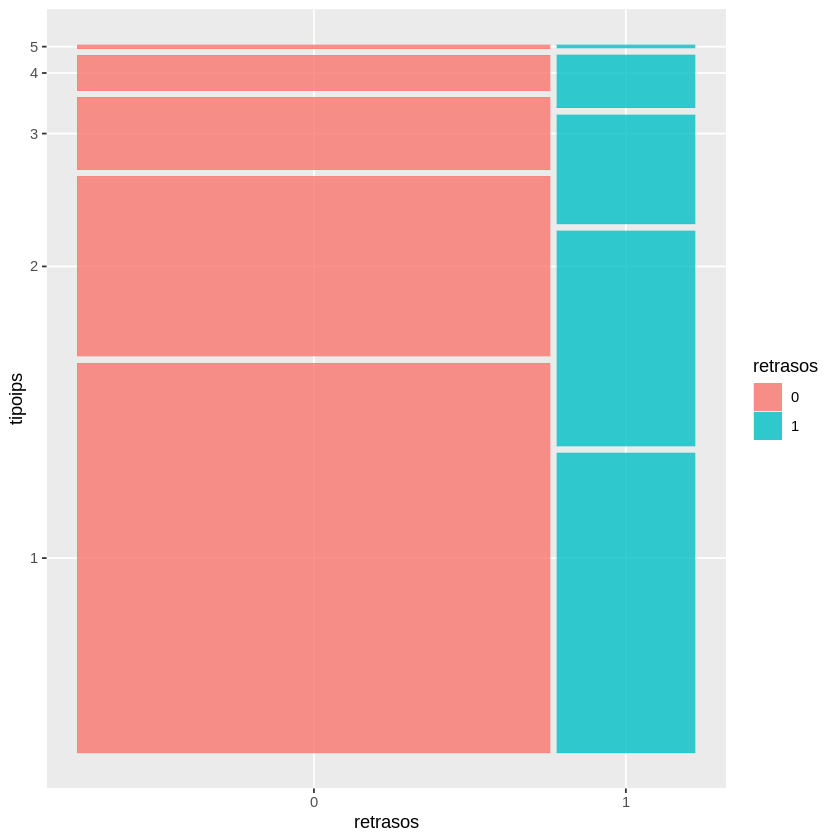

In [ ]:
library(ggmosaic)
ggplot(data=cartera)+geom_mosaic(aes(x=product(tipoips,retrasos),fill=retrasos))


Aquí termina el notebook de descriptiva

In [ ]:
library(tidyverse)